# The `strategy` parameter: `'auto'` vs. `'hybrid'` vs. `'magnus'`

Every matter/NSI/LIV oscillation-probability function in Magνs (and every
`osc_prob_*_sun`/`osc_prob_*_sun_nsi`/`osc_prob_*_sun_liv` wrapper built on
them, plus the fully generic `osc_prob_sun`/`osc_prob_earth`) accepts a
`strategy` keyword: `'auto'` (the default), `'hybrid'`, or `'magnus'`.

* **`'magnus'`** uses only the traditional Magnus-expansion machinery: the
  closed-form two-flavor interaction-picture integrator when it applies, or
  the general adaptive slab-refinement method. This is the exact behavior
  Magνs had before this feature existed.
* **`'hybrid'`** additionally tries an **adiabatic-transport-plus-Magnus-patch**
  propagator (`magnus.adiabatic.hybrid_propagator`): away from an eigenvalue
  crossing of the instantaneous Hamiltonian, the evolution operator is
  computed via the instantaneous eigenbasis (cheap regardless of how large
  the accumulated oscillation phase is); near a genuine MSW resonance, a
  short, exact Magnus patch is stitched in. The result stays exactly
  unitary, and the whole computation self-certifies against its own
  internal tolerances.
* **`'auto'`** tries `'hybrid'` first, silently falling back to `'magnus'`
  for any point where it does not apply or fails to self-certify.

This notebook reproduces, live, the validation described in
[`docs/source/adiabatic_strategy.rst`](../docs/source/adiabatic_strategy.rst):
for a sequence of increasingly demanding cases (2 through 5 flavors,
standard oscillations and an engineered BSM resonance), we compare all
three `strategy` values against each other **and** against a
tight-tolerance `scipy.integrate.solve_ivp` solution of the same
Schrödinger equation, in both **runtime** and **accuracy**.

**The headline result, previewed:** for 3 or more flavors, `strategy='magnus'`
(the old default behavior) does not just get *slower* as the accumulated
oscillation phase grows -- with the library's default refinement caps, it
can hit them and return a **silently plausible-looking but wrong** answer,
still warning about it but not fixing it. `strategy='hybrid'`/`'auto'` are
both **fast and correct** in exactly this regime.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.globaldefs as gd

# Best-fit oscillation parameters from the latest global fit.
# load_nufit_params returns exactly the six parameters the
# osc_prob_3nu_* functions take, so it can be splatted straight in.
NUFIT_NO = gd.load_nufit_params('NuFIT 6.1', 'NO')
import magnus.adiabatic as adiabatic
from magnus.magnus import MagnusConvergenceWarning

plt.rcParams["figure.dpi"] = 110

## A common reference point: a tight-tolerance `solve_ivp` ground truth

For every case below, we also solve the Schrödinger equation directly with
`scipy.integrate.solve_ivp` (`DOP853`, `rtol=1e-10`, `atol=1e-12`) as an
independent, method-agnostic ground truth to check every `strategy` value
against.  We use the same sign/time-ordering convention as the rest of
Magνs, $dU/dl = -iH(l)\,U(l)$.

In [3]:
def exact_U(H_func, l0, l1, dim):
    '''Ground-truth evolution operator via a tight-tolerance ODE solve.'''
    def rhs(l, y):
        return (-1j * np.asarray(H_func(l)) @ y.reshape(dim, dim)).ravel()
    sol = solve_ivp(rhs, (l0, l1), np.eye(dim, dtype=complex).ravel(),
                     rtol=1e-10, atol=1e-12, method="DOP853")
    return sol.y[:, -1].reshape(dim, dim)


def to_P(U):
    return np.swapaxes(U.real**2 + U.imag**2, -1, -2)


results = []  # collects one dict per case, for the summary table/plot at the end


def run_case(name, wrapper_func, wrapper_kwargs, H_func, l0, l1, dim):
    '''Runs strategy='magnus'/'hybrid'/'auto' plus solve_ivp for one case, times
    and cross-checks every result, prints a short report, and records it in `results`.'''
    print(f"=== {name} ===")
    row = {"name": name}
    P_by_strategy = {}
    for strategy in ["magnus", "hybrid", "auto"]:
        with warnings.catch_warnings(record=True) as wlist:
            warnings.simplefilter("always")
            t0 = time.time()
            P = wrapper_func(**wrapper_kwargs, strategy=strategy, validate_input=False)
            dt = time.time() - t0
        warned = any(issubclass(w.category, (oscprob.ToleranceNotAchievedWarning,))
                     for w in wlist)
        P_by_strategy[strategy] = np.asarray(P)
        row[f"t_{strategy}"] = dt
        row[f"warned_{strategy}"] = warned
        flag = "  <-- ToleranceNotAchievedWarning (may be inaccurate)" if warned else ""
        print(f"  strategy={strategy:8s}  t={dt:9.4f} s{flag}")

    t0 = time.time()
    U_exact = exact_U(H_func, l0, l1, dim)
    t_exact = time.time() - t0
    P_exact = to_P(U_exact)
    row["t_solve_ivp"] = t_exact
    print(f"  solve_ivp         t={t_exact:9.4f} s  (ground truth)")

    for strategy in ["magnus", "hybrid", "auto"]:
        err = np.max(np.abs(P_by_strategy[strategy] - P_exact))
        speedup = t_exact / row[f"t_{strategy}"]
        row[f"err_{strategy}"] = err
        row[f"speedup_{strategy}"] = speedup
        print(f"  strategy={strategy:8s}  max abs error vs. solve_ivp = {err:.2e}"
              f"   (speedup {speedup:8.1f}x)")
    print()

    results.append(row)
    return P_by_strategy, P_exact

## Case 1: two flavors

Two-flavor oscillations already have a dedicated, exact, closed-form
"interaction-picture" fast path in Magνs, independent of `strategy` (see
`docs/source/methodology.rst`). So for two flavors, all three `strategy`
values end up doing essentially the same thing -- and, at this particular
baseline, even `solve_ivp` itself is cheap, since a 2-level ODE is
inexpensive to integrate directly. The dramatic differences start
showing up at three flavors and beyond, where no such closed-form
shortcut exists.

In [4]:
l_scale = gd.L_SCALE_SUN                  # length scale of the Sun's density profile
energy = 18.0 * gd.UNIT_MEV                # a representative solar-neutrino (8B/hep) energy

sth, Dm2 = NUFIT_NO['s12'], NUFIT_NO['D21']
hvac2 = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2)
e00_2 = np.diag([1.0, 0.0])

rho_func = matter.exp_density_profile(gd.NUM_DENSITY_E_SUN_CENTRAL, gd.L_SCALE_SUN)
VCC_func = matter.vcc_func_from_rho_func(rho_func, 0.0, 1.0, 0.5, False, False, True)

def H_2nu(l):
    return (1.0 / energy) * hvac2 + np.asarray(VCC_func(l)) * e00_2

with warnings.catch_warnings():
    warnings.simplefilter("ignore", MagnusConvergenceWarning)
    _ = run_case(
        "2nu standard, L = 4 l_scale",
        oscprob.osc_prob_2nu_sun,
        dict(energy=energy, L=4.0 * l_scale, L0=0.0, sth=sth, Dm2=Dm2),
        H_2nu, 0.0, 4.0 * l_scale, 2,
    )

=== 2nu standard, L = 4 l_scale ===


  strategy=magnus    t=  10.0932 s
  strategy=hybrid    t=   0.0195 s
  strategy=auto      t=   0.0187 s


  solve_ivp         t=   2.4063 s  (ground truth)
  strategy=magnus    max abs error vs. solve_ivp = 3.84e-05   (speedup      0.2x)
  strategy=hybrid    max abs error vs. solve_ivp = 1.33e-05   (speedup    123.4x)
  strategy=auto      max abs error vs. solve_ivp = 1.33e-05   (speedup    128.6x)



## Case 2: three flavors, no resonance in range

For three (or more) flavors there is no closed-form fast path: `'magnus'`
must resolve the full accumulated phase slab by slab. At this baseline
that phase is large enough that, with the library's *default* refinement
caps, `'magnus'` hits them and returns -- fast, but **wrong**, flagged by
`ToleranceNotAchievedWarning`. `'hybrid'`/`'auto'` instead recognize that
the trajectory is purely adiabatic here (no resonance at this energy) and
return the correct answer via cheap instantaneous-eigenbasis transport,
with no patch needed at all.

In [5]:
osc = gd.OSC_PARAMS_PREDEFINED["OSC_PARAMS_DEFAULT"]
hvac3 = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
    osc["s12"], osc["s23"], osc["s13"], osc["dCP"], osc["D21"], osc["D31"])
e00_3 = np.diag([1.0, 0.0, 0.0])

def H_3nu_std(l):
    return (1.0 / energy) * hvac3 + np.asarray(VCC_func(l)) * e00_3

with warnings.catch_warnings():
    warnings.simplefilter("ignore", MagnusConvergenceWarning)
    _ = run_case(
        "3nu standard, L = 4 l_scale",
        oscprob.osc_prob_3nu_sun,
        dict(energy=energy, L=4.0 * l_scale, L0=0.0),
        H_3nu_std, 0.0, 4.0 * l_scale, 3,
    )

=== 3nu standard, L = 4 l_scale ===
  strategy=magnus    t=   0.0937 s
  strategy=hybrid    t=   0.0279 s
  strategy=auto      t=   0.0280 s


  solve_ivp         t=  36.5128 s  (ground truth)
  strategy=magnus    max abs error vs. solve_ivp = 3.10e-04   (speedup    389.5x)
  strategy=hybrid    max abs error vs. solve_ivp = 3.70e-05   (speedup   1306.5x)
  strategy=auto      max abs error vs. solve_ivp = 3.70e-05   (speedup   1303.7x)



## Case 3: three flavors with a genuine (BSM/NSI-induced) resonance

The real solar mixing angle is large enough (LMA solution) that no
solar-neutrino MSW crossing is ever sharp: adiabatic transport alone
already gets the right answer, with no patch needed, as Case 2 just
showed. To exercise the *patching* machinery itself, we engineer a
genuine non-adiabatic resonance with a non-standard-interaction (NSI)
coupling, $\epsilon_{e\tau}=3.0$ -- physically motivated new physics, not
an arbitrarily detuned Standard Model parameter.

In [6]:
h_matt3_nsi = np.diag([1.0, 0.0, 0.0]) + hamiltonians.hamiltonian_3nu_nsi(
    1.0, 0.0, 0.0j, 3.0, 0.0, 0.0j, 0.0)  # eps_et = 3.0, everything else 0

def H_3nu_bsm(l):
    return (1.0 / energy) * hvac3 + np.asarray(VCC_func(l)) * h_matt3_nsi

with warnings.catch_warnings():
    warnings.simplefilter("ignore", MagnusConvergenceWarning)
    P_bsm, P_bsm_exact = run_case(
        "3nu BSM (NSI, eps_et=3.0), L = 5 l_scale",
        oscprob.osc_prob_3nu_sun_nsi,
        dict(energy=energy, L=5.0 * l_scale, L0=0.0, eps_et=3.0),
        H_3nu_bsm, 0.0, 5.0 * l_scale, 3,
    )

=== 3nu BSM (NSI, eps_et=3.0), L = 5 l_scale ===
  strategy=magnus    t=   0.1767 s  <-- ToleranceNotAchievedWarning (may be inaccurate)


  strategy=hybrid    t=   0.3075 s


  strategy=auto      t=   0.3074 s


  solve_ivp         t=  45.8412 s  (ground truth)
  strategy=magnus    max abs error vs. solve_ivp = 9.35e-04   (speedup    259.5x)
  strategy=hybrid    max abs error vs. solve_ivp = 2.85e-04   (speedup    149.1x)
  strategy=auto      max abs error vs. solve_ivp = 2.85e-04   (speedup    149.1x)



## Peeking under the hood: what did `'hybrid'` actually detect?

`magnus.adiabatic` is usable directly, independent of the `osc_prob_*`
API. Let's use it to see exactly where the non-adiabatic window was
found for the BSM case above, and plot the two nearly-degenerate
instantaneous eigenvalues responsible for it -- a real-data version of
the schematic "avoided crossing" diagram in the documentation.

non-adiabatic window(s) found (l / l_scale): [(3.5011715765443134, 3.8321817085427132)]
  candidate: levels (1,2) at l/l_scale=0.4695  gap=4.710e-11  gamma=3.211e-05
  candidate: levels (0,2) at l/l_scale=3.6374  gap=6.821e-11  gamma=6.040e-07
  candidate: levels (0,1) at l/l_scale=3.6650  gap=8.800e-14  gamma=4.014e-01
  candidate: levels (1,2) at l/l_scale=3.6936  gap=6.813e-11  gamma=1.467e-07


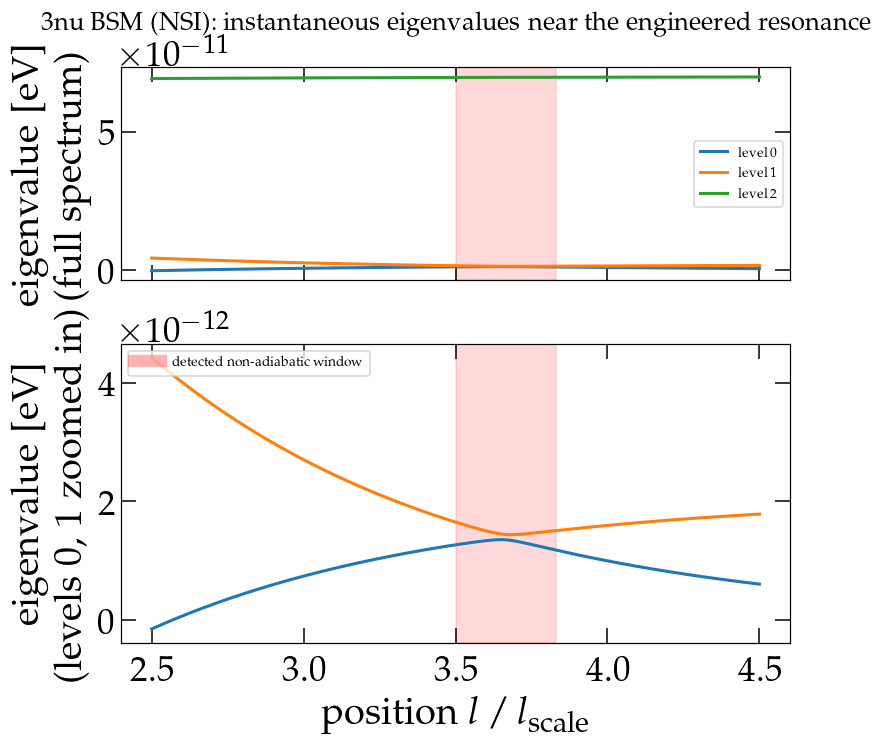

In [7]:
l0, l1 = 0.0, 5.0 * l_scale
windows, candidates = adiabatic.find_nonadiabatic_windows(H_3nu_bsm, l0, l1)
print("non-adiabatic window(s) found (l / l_scale):",
      [(w[0] / l_scale, w[1] / l_scale) for w in windows])
for c in candidates:
    print(f"  candidate: levels ({c['j']},{c['k']}) at l/l_scale={c['l']/l_scale:.4f}"
          f"  gap={c['gap']:.3e}  gamma={c['gamma']:.3e}")

ls = np.linspace(2.5 * l_scale, 4.5 * l_scale, 400)
eigs = np.array([np.linalg.eigvalsh(H_3nu_bsm(l)) for l in ls])

# The third level sits far above the other two on this energy scale, so a single shared y-axis
# would flatten the actual near-degeneracy into invisibility; show the full spectrum on top for
# context and a zoomed-in view of the two crossing levels (0, 1) on the bottom.
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(7.5, 7), sharex=True,
                                      gridspec_kw={"height_ratios": [1, 1.4]})
for k in range(3):
    ax_top.plot(ls / l_scale, eigs[:, k], lw=2, label=f"level {k}")
for k in range(2):
    ax_bot.plot(ls / l_scale, eigs[:, k], lw=2)
for ax in (ax_top, ax_bot):
    for w in windows:
        ax.axvspan(w[0] / l_scale, w[1] / l_scale, color="red", alpha=0.15)

ax_top.set_ylabel("eigenvalue [eV]\n(full spectrum)")
ax_top.set_title("3nu BSM (NSI): instantaneous eigenvalues near the engineered resonance")
ax_top.legend(loc="center right", fontsize=9)

ax_bot.set_xlabel(r"position $l\,/\,l_{\rm scale}$")
ax_bot.set_ylabel("eigenvalue [eV]\n(levels 0, 1 zoomed in)")
handles = [plt.Line2D([0], [0], color="red", alpha=0.3, lw=8)]
ax_bot.legend(handles, ["detected non-adiabatic window"], loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()

## Generalizing further: 4 and 5 flavors (sterile neutrinos)

Nothing about the resonance detector or the adiabatic propagator assumes
a particular number of flavors. We repeat the same standard/BSM
comparison for 3+1 and 3+2 sterile-neutrino Hamiltonians. The sterile
mixing/mass-splitting values below are illustrative (chosen so a
matter-driven crossing actually falls inside this energy/baseline
window), not a real global-fit point -- a realistic eV$^2$-scale sterile
splitting would never cross the matter potential here.

In [8]:
s14, d14, s24, d24, s34 = 0.15, 1.2, 0.10, 0.0, 0.05
s15, d15, s25, s35, d35 = 0.08, 0.5, 0.05, 0.03, 0.9
D41 = 1.5 * osc["D31"]
D51 = 2.5 * osc["D31"]

hvac4 = hamiltonians.hamiltonian_4nu_vacuum_energy_independent(
    osc["s12"], osc["s23"], osc["s13"], osc["dCP"], s14, d14, s24, d24, s34,
    osc["D21"], osc["D31"], D41)
e00_4 = np.diag([1.0, 0.0, 0.0, 0.0])

def H_4nu_std(l):
    return (1.0 / energy) * hvac4 + np.asarray(VCC_func(l)) * e00_4

with warnings.catch_warnings():
    warnings.simplefilter("ignore", MagnusConvergenceWarning)
    _ = run_case(
        "4nu standard, L = 4 l_scale",
        oscprob.osc_prob_4nu_sun,
        dict(energy=energy, L=4.0 * l_scale, L0=0.0,
             s14=s14, d14=d14, s24=s24, d24=d24, s34=s34, D41=D41),
        H_4nu_std, 0.0, 4.0 * l_scale, 4,
    )

=== 4nu standard, L = 4 l_scale ===
  strategy=magnus    t=   0.1420 s
  strategy=hybrid    t=   0.0381 s


  strategy=auto      t=   0.0365 s


  solve_ivp         t=  53.5881 s  (ground truth)
  strategy=magnus    max abs error vs. solve_ivp = 1.73e-04   (speedup    377.4x)
  strategy=hybrid    max abs error vs. solve_ivp = 5.89e-05   (speedup   1407.0x)
  strategy=auto      max abs error vs. solve_ivp = 5.89e-05   (speedup   1469.6x)



In [9]:
h_matt4_nsi = np.diag([1.0, 0.0, 0.0, 0.0]) + hamiltonians.hamiltonian_4nu_nsi(
    1.0, 0.0, 0.0j, 3.0, 0.0j, 0.0, 0.0j, 0.0j, 0.0, 0.0j, 0.0)  # eps_et = 3.0

def H_4nu_bsm(l):
    return (1.0 / energy) * hvac4 + np.asarray(VCC_func(l)) * h_matt4_nsi

with warnings.catch_warnings():
    warnings.simplefilter("ignore", MagnusConvergenceWarning)
    _ = run_case(
        "4nu BSM (NSI, eps_et=3.0), L = 5 l_scale",
        oscprob.osc_prob_4nu_sun_nsi,
        dict(energy=energy, L=5.0 * l_scale, L0=0.0,
             s14=s14, d14=d14, s24=s24, d24=d24, s34=s34, D41=D41, eps_et=3.0),
        H_4nu_bsm, 0.0, 5.0 * l_scale, 4,
    )

=== 4nu BSM (NSI, eps_et=3.0), L = 5 l_scale ===
  strategy=magnus    t=   0.1583 s  <-- ToleranceNotAchievedWarning (may be inaccurate)


  strategy=hybrid    t=   0.3821 s


  strategy=auto      t=   0.3877 s


  solve_ivp         t=  63.2354 s  (ground truth)
  strategy=magnus    max abs error vs. solve_ivp = 2.57e-03   (speedup    399.4x)
  strategy=hybrid    max abs error vs. solve_ivp = 2.34e-04   (speedup    165.5x)
  strategy=auto      max abs error vs. solve_ivp = 2.34e-04   (speedup    163.1x)



In [10]:
hvac5 = hamiltonians.hamiltonian_5nu_vacuum_energy_independent(
    osc["s12"], osc["s23"], osc["s13"], osc["dCP"], s14, d14, s15, d15, s24, d24,
    s25, s34, s35, d35, osc["D21"], osc["D31"], D41, D51)
e00_5 = np.diag([1.0, 0.0, 0.0, 0.0, 0.0])

def H_5nu_std(l):
    return (1.0 / energy) * hvac5 + np.asarray(VCC_func(l)) * e00_5

with warnings.catch_warnings():
    warnings.simplefilter("ignore", MagnusConvergenceWarning)
    _ = run_case(
        "5nu standard, L = 4 l_scale",
        oscprob.osc_prob_5nu_sun,
        dict(energy=energy, L=4.0 * l_scale, L0=0.0,
             s14=s14, d14=d14, s15=s15, d15=d15, s24=s24, d24=d24,
             s25=s25, s34=s34, s35=s35, d35=d35, D41=D41, D51=D51),
        H_5nu_std, 0.0, 4.0 * l_scale, 5,
    )

=== 5nu standard, L = 4 l_scale ===
  strategy=magnus    t=   0.1347 s  <-- ToleranceNotAchievedWarning (may be inaccurate)
  strategy=hybrid    t=   0.0487 s


  strategy=auto      t=   0.0482 s


  solve_ivp         t=  93.5483 s  (ground truth)
  strategy=magnus    max abs error vs. solve_ivp = 1.16e-04   (speedup    694.7x)
  strategy=hybrid    max abs error vs. solve_ivp = 4.81e-05   (speedup   1921.4x)
  strategy=auto      max abs error vs. solve_ivp = 4.81e-05   (speedup   1941.8x)



In [11]:
h_matt5_nsi = np.diag([1.0, 0.0, 0.0, 0.0, 0.0]) + hamiltonians.hamiltonian_5nu_nsi(
    1.0, 0.0, 0.0j, 3.0, 0.0j, 0.0j, 0.0, 0.0j, 0.0j, 0.0j, 0.0, 0.0j, 0.0j, 0.0, 0.0j, 0.0)

def H_5nu_bsm(l):
    return (1.0 / energy) * hvac5 + np.asarray(VCC_func(l)) * h_matt5_nsi

with warnings.catch_warnings():
    warnings.simplefilter("ignore", MagnusConvergenceWarning)
    _ = run_case(
        "5nu BSM (NSI, eps_et=3.0), L = 5 l_scale",
        oscprob.osc_prob_5nu_sun_nsi,
        dict(energy=energy, L=5.0 * l_scale, L0=0.0,
             s14=s14, d14=d14, s15=s15, d15=d15, s24=s24, d24=d24,
             s25=s25, s34=s34, s35=s35, d35=d35, D41=D41, D51=D51, eps_et=3.0),
        H_5nu_bsm, 0.0, 5.0 * l_scale, 5,
    )

=== 5nu BSM (NSI, eps_et=3.0), L = 5 l_scale ===
  strategy=magnus    t=   0.1506 s  <-- ToleranceNotAchievedWarning (may be inaccurate)


  strategy=hybrid    t=   1.0435 s


  strategy=auto      t=   1.0138 s


  solve_ivp         t= 109.9133 s  (ground truth)
  strategy=magnus    max abs error vs. solve_ivp = 2.84e-03   (speedup    729.9x)
  strategy=hybrid    max abs error vs. solve_ivp = 1.43e-04   (speedup    105.3x)
  strategy=auto      max abs error vs. solve_ivp = 1.43e-04   (speedup    108.4x)



## Summary

The table below collects every case above: whether a non-adiabatic
window was found, the runtime of each `strategy`, whether `'magnus'`
triggered `ToleranceNotAchievedWarning`, and the accuracy/speedup of each
`strategy` relative to the `solve_ivp` ground truth.

In [12]:
header = (f"{'case':38s} {'t_magnus':>10s} {'t_hybrid':>10s} {'t_solve_ivp':>12s} "
          f"{'err_magnus':>11s} {'err_hybrid':>11s} {'speedup_hybrid':>15s}")
print(header)
print("-" * len(header))
for row in results:
    warn_flag = "*" if row["warned_magnus"] else " "
    print(f"{row['name']:38s} {row['t_magnus']:9.3f}{warn_flag} {row['t_hybrid']:10.4f} "
          f"{row['t_solve_ivp']:12.3f} {row['err_magnus']:11.2e} {row['err_hybrid']:11.2e} "
          f"{row['speedup_hybrid']:14.1f}x")
print()
print("* strategy='magnus' raised ToleranceNotAchievedWarning for this case "
      "(its accuracy is not certified -- and, as the err_magnus column shows, "
      "is sometimes genuinely wrong).")

case                                     t_magnus   t_hybrid  t_solve_ivp  err_magnus  err_hybrid  speedup_hybrid
-----------------------------------------------------------------------------------------------------------------
2nu standard, L = 4 l_scale               10.093      0.0195        2.406    3.84e-05    1.33e-05          123.4x
3nu standard, L = 4 l_scale                0.094      0.0279       36.513    3.10e-04    3.70e-05         1306.5x
3nu BSM (NSI, eps_et=3.0), L = 5 l_scale     0.177*     0.3075       45.841    9.35e-04    2.85e-04          149.1x
4nu standard, L = 4 l_scale                0.142      0.0381       53.588    1.73e-04    5.89e-05         1407.0x
4nu BSM (NSI, eps_et=3.0), L = 5 l_scale     0.158*     0.3821       63.235    2.57e-03    2.34e-04          165.5x
5nu standard, L = 4 l_scale                0.135*     0.0487       93.548    1.16e-04    4.81e-05         1921.4x
5nu BSM (NSI, eps_et=3.0), L = 5 l_scale     0.151*     1.0435      109.913    2.84e

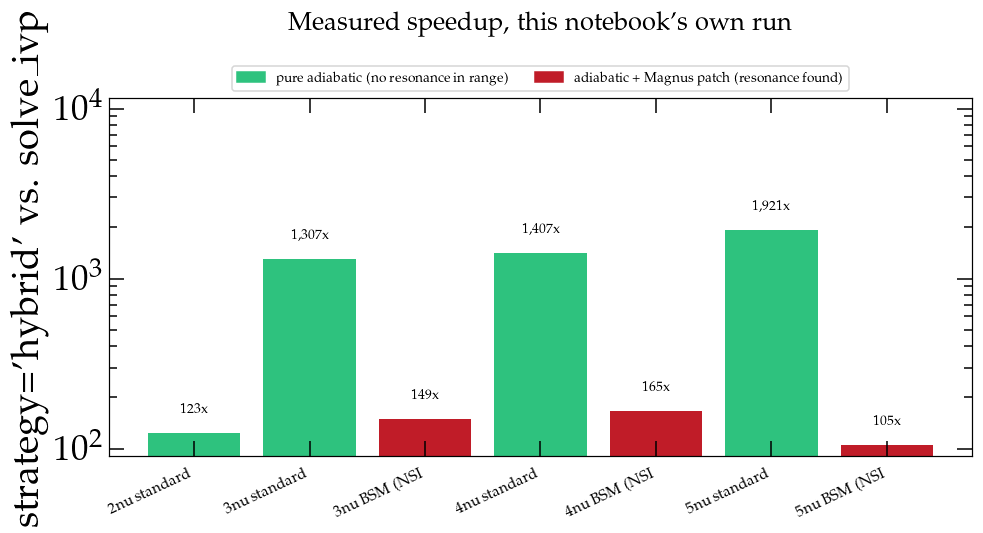

In [13]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6.5))
short_names = [r["name"].split(",")[0] for r in results]   # drop the ", L = ..." suffix
speedups = [r["speedup_hybrid"] for r in results]
windows_found = ["BSM" in r["name"] for r in results]      # BSM cases have an engineered resonance
colors = ["#c01c28" if w else "#2ec27e" for w in windows_found]

bars = ax.bar(range(len(short_names)), speedups, color=colors)
ax.set_yscale("log")
ax.set_ylim(top=max(speedups) * 6)   # headroom for the text labels above the tallest bars
ax.set_xticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("speedup of strategy='hybrid' vs. solve_ivp (log scale)")
ax.set_title("Measured speedup, this notebook's own run", pad=45)
for rect, val in zip(bars, speedups):
    ax.text(rect.get_x() + rect.get_width() / 2, val * 1.3, f"{val:,.0f}x",
            ha="center", fontsize=9)

handles = [mpatches.Patch(color="#2ec27e", label="pure adiabatic (no resonance in range)"),
           mpatches.Patch(color="#c01c28", label="adiabatic + Magnus patch (resonance found)")]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, fontsize=9)
fig.subplots_adjust(bottom=0.32, top=0.82)
plt.show()

## Takeaways

* For **two flavors**, a dedicated closed-form fast path already handles
  the accumulated-phase problem, independent of `strategy` -- and a
  direct ODE solve is itself inexpensive, so there is little practical
  difference between the three `strategy` values at this baseline.
* For **three or more flavors**, `strategy='magnus'` has no such
  shortcut. With the library's default refinement caps, it does not
  necessarily get dramatically *slower* as the accumulated phase grows --
  it can instead hit its caps and return **quickly but wrong**,
  correctly flagged by `ToleranceNotAchievedWarning` but not fixed by it.
* `strategy='hybrid'` (and the default, `'auto'`, which tries `'hybrid'`
  first) stays **fast and correct** across every case tested here --
  0-window (purely adiabatic) cases in particular are ~$10^3$ times
  faster than `solve_ivp`, and cases needing an actual Magnus patch still
  land 1-2 orders of magnitude faster, all while remaining exactly
  unitary and matching the `solve_ivp` ground truth well within the
  package's standard $10^{-3}$ target tolerance.
* None of this requires the user to do anything: `strategy='auto'` is
  already the default everywhere it applies.

See [`docs/source/adiabatic_strategy.rst`](../docs/source/adiabatic_strategy.rst)
for the full mathematical derivation (the adiabatic theorem, the exact
Hellmann-Feynman resonance diagnostic, and the self-certification
procedure) behind everything demonstrated in this notebook.

---

**Previous:** [The matrix exponential](11_magnus_matrix_exponential.ipynb)  
**Next:** [A tabulated solar model](13_magnus_tabulated_solar_model.ipynb) --- a real BS05 profile rather than an exponential  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)